<a href="https://colab.research.google.com/github/malysirina-collab/Diplom/blob/main/Api2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install newsapi-python
!pip install nltk
!pip install tqdm
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


In [3]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from newsapi import NewsApiClient
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
API_KEY = "e76bfca5503a4372ba2022672e31b4fc"
newsapi = NewsApiClient(api_key=API_KEY)

In [6]:
topics = {
    "economics": "economy OR finance",
    "politics": "politics OR government",
    "business": "business OR market",
    "technology": "technology OR tech"
}

all_articles = []

for label, query in topics.items():
    print(f"\nСобираем категорию: {label}")

    response = newsapi.get_everything(
        q=query,
        language="en",
        sort_by="relevancy",
        page_size=100
    )

    articles = response.get("articles", [])
    print("Найдено:", len(articles))

    for item in articles:
        text = item.get("content") or item.get("description")
        if text:
            all_articles.append({
                "label": label,
                "text": text
            })

df = pd.DataFrame(all_articles)

print("\nДо удаления дубликатов:", df.shape)

# Удаление полных дубликатов
df.drop_duplicates(subset=["text"], inplace=True)

# Удаление слишком коротких текстов
df = df[df["text"].str.len() > 100]

print("После очистки:", df.shape)
print(df["label"].value_counts())

print("\nРазмер датасета:", df.shape)
print(df["label"].value_counts())


Собираем категорию: economics
Найдено: 98

Собираем категорию: politics
Найдено: 86

Собираем категорию: business
Найдено: 89

Собираем категорию: technology
Найдено: 88

До удаления дубликатов: (361, 2)
После очистки: (326, 2)
label
economics     88
business      83
politics      81
technology    74
Name: count, dtype: int64

Размер датасета: (326, 2)
label
economics     88
business      83
politics      81
technology    74
Name: count, dtype: int64


Визуализация распределения классов

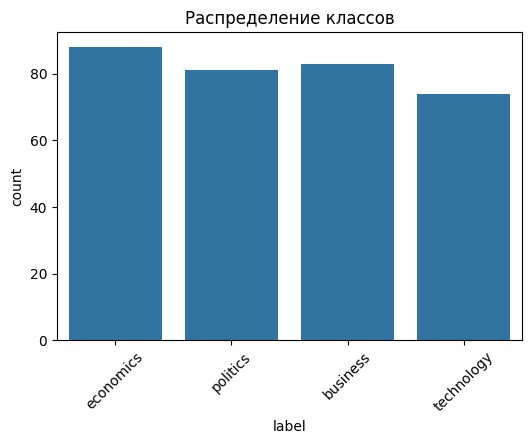

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Распределение классов")
plt.xticks(rotation=45)
plt.show()

Предобработка текста

100%|██████████| 326/326 [00:00<00:00, 2527.73it/s]


sentiment_label
positive    146
neutral      92
negative     88
Name: count, dtype: int64


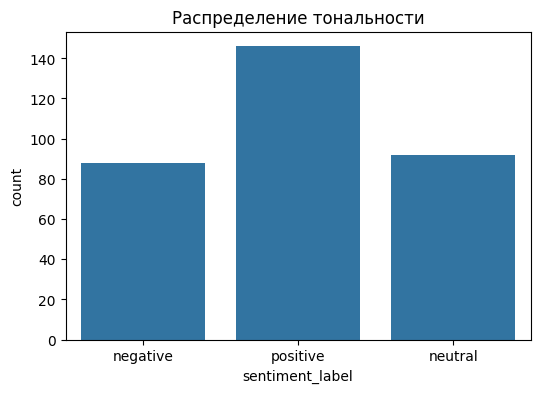

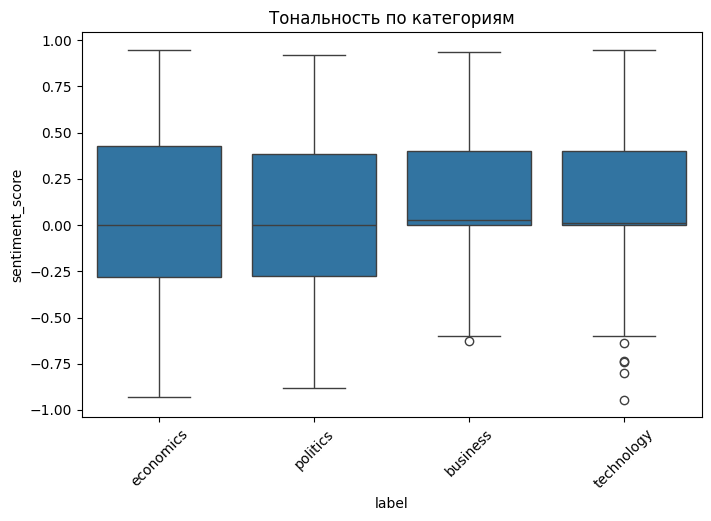

In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'<.*?>', ' ', str(text))
    text = re.sub(r'[^a-zA-Z ]', ' ', text).lower()
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 2
    ]
    return " ".join(tokens)

tqdm.pandas()
df["clean_text"] = df["text"].progress_apply(preprocess_text)
# --- Анализ тональности ---
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score["compound"]

df["sentiment_score"] = df["text"].apply(get_sentiment)

# Классификация тональности
def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment_score"].apply(sentiment_label)

print(df["sentiment_label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df["sentiment_label"])
plt.title("Распределение тональности")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="sentiment_score", data=df)
plt.title("Тональность по категориям")
plt.xticks(rotation=45)
plt.show()

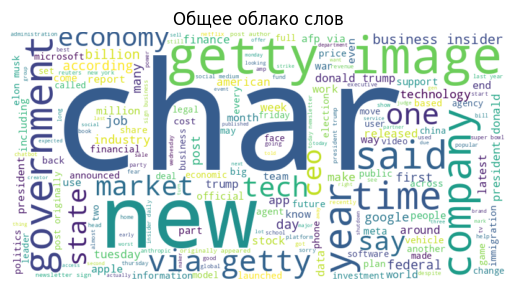

In [10]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Общее облако слов")
plt.show()

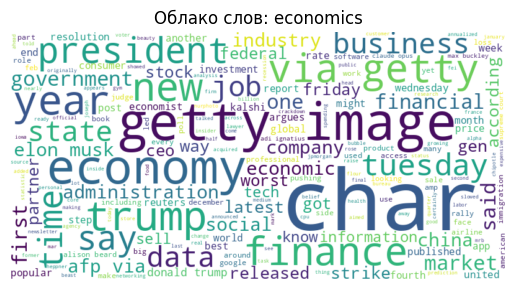

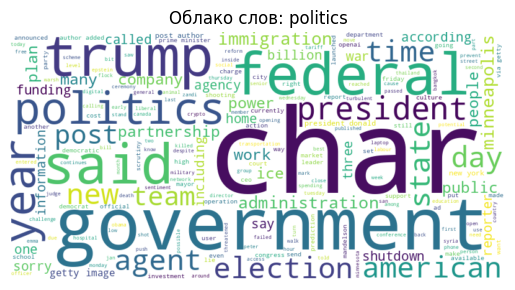

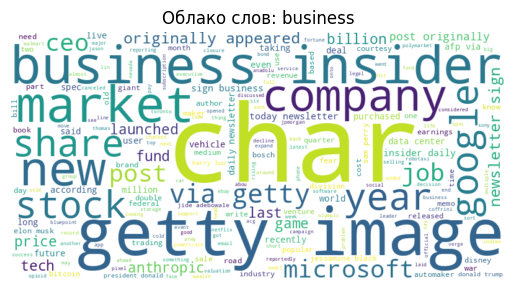

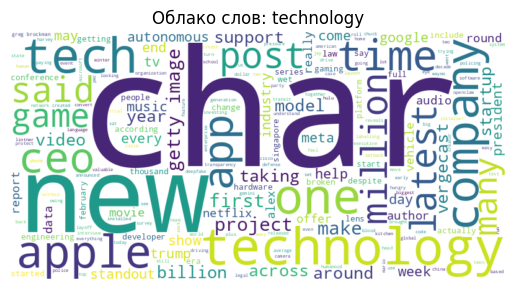

In [11]:
for category in df["label"].unique():
    text = " ".join(df[df["label"] == category]["clean_text"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Облако слов: {category}")
    plt.show()

Анализ частоты слов

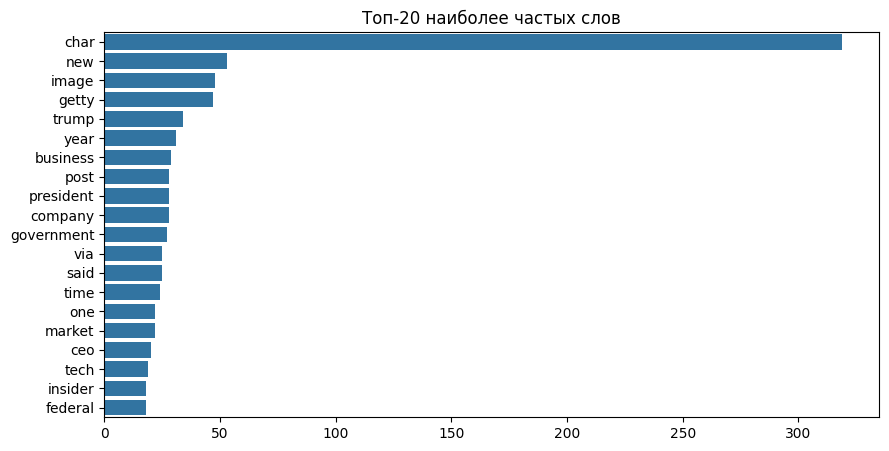

In [12]:
all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Топ-20 наиболее частых слов")
plt.show()

Анализ биграмм

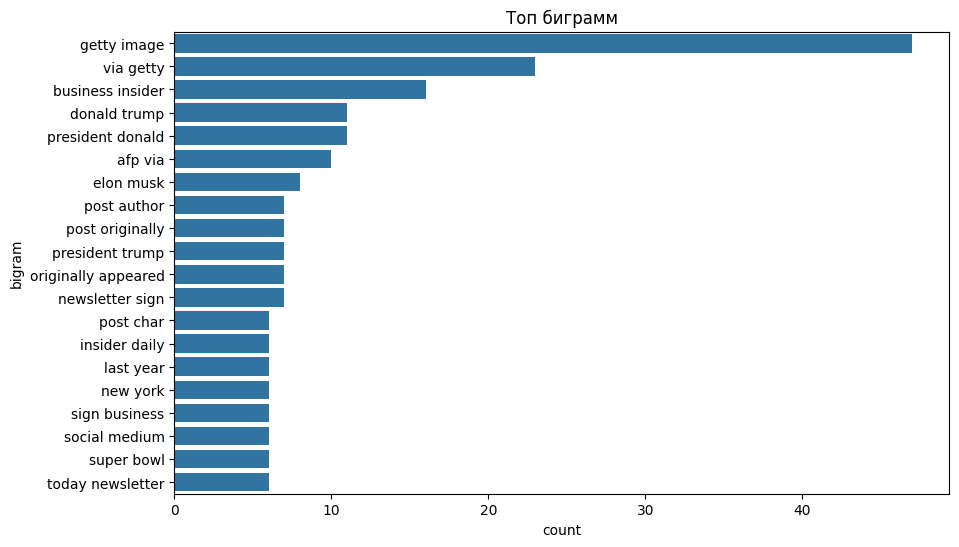

In [13]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(df["clean_text"])

bigram_counts = np.sum(X_bigrams.toarray(), axis=0)
bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "bigram": bigram_names,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=bigram_df, x="count", y="bigram")
plt.title("Топ биграмм")
plt.show()

Балансировка классов

In [14]:
df_balanced = []

for label in df["label"].unique():
    df_class = df[df["label"] == label]
    df_resampled = resample(
        df_class,
        replace=True,
        n_samples=df["label"].value_counts().max(),
        random_state=42
    )
    df_balanced.append(df_resampled)

df = pd.concat(df_balanced)

print("После балансировки:")
print(df["label"].value_counts())

После балансировки:
label
economics     88
politics      88
business      88
technology    88
Name: count, dtype: int64


Разделение данных

In [15]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Построение моделей

In [16]:
models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2))),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2))),
        ("model", LinearSVC(class_weight="balanced"))
    ]),

    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2))),
        ("model", RandomForestClassifier(class_weight="balanced"))
    ])
}

Кросс-валидация

In [17]:
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.6867
Linear SVM: 0.6867
Random Forest: 0.7045


Визуализация сравнения моделей

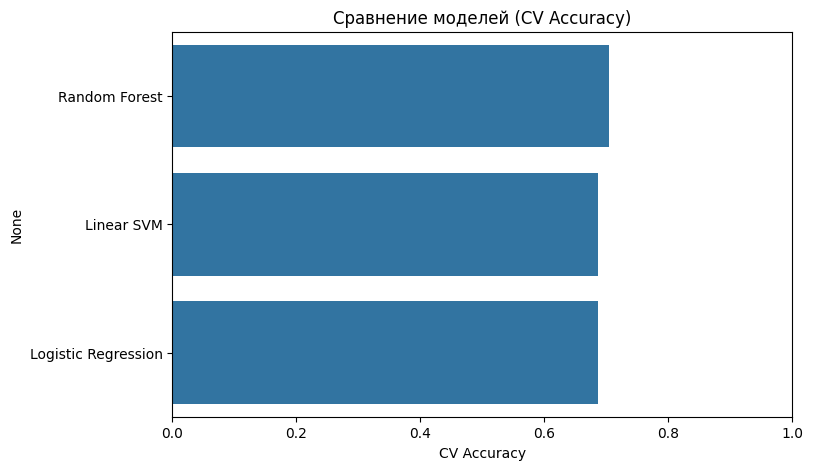

In [18]:
results_df = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["CV Accuracy"]
).sort_values(by="CV Accuracy", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=results_df["CV Accuracy"], y=results_df.index)
plt.title("Сравнение моделей (CV Accuracy)")
plt.xlim(0,1)
plt.show()

Обучение лучшей модели

In [19]:
best_model_name = max(results, key=results.get)
print("Лучшая модель:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Сохранение модели
joblib.dump(best_model, "best_news_classifier.pkl")
print("Модель сохранена в файл best_news_classifier.pkl")

y_pred = best_model.predict(X_test)

Лучшая модель: Random Forest
Модель сохранена в файл best_news_classifier.pkl


Оценка качества

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8169014084507042
              precision    recall  f1-score   support

    business       0.80      0.89      0.84        18
   economics       1.00      0.47      0.64        17
    politics       0.81      0.94      0.87        18
  technology       0.77      0.94      0.85        18

    accuracy                           0.82        71
   macro avg       0.85      0.81      0.80        71
weighted avg       0.84      0.82      0.80        71



Confusion Matrix

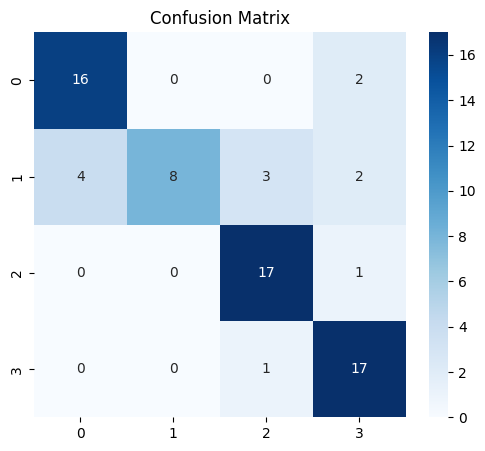

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

ROC-AUC (многоклассовая)

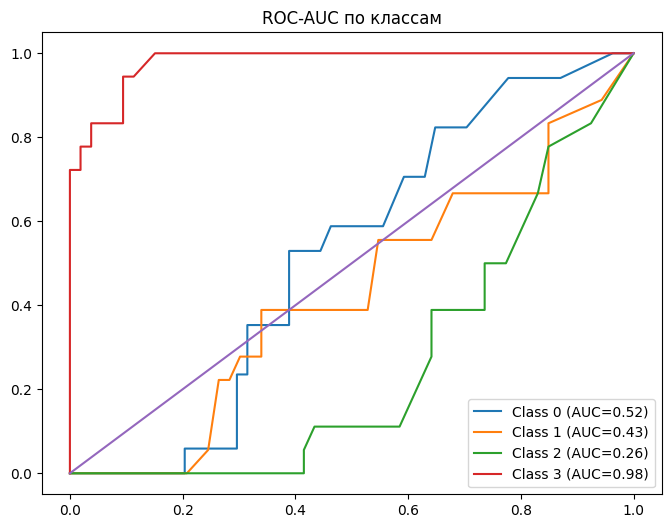

In [28]:
y_test_bin = label_binarize(y_test, classes=y.unique())
n_classes = y_test_bin.shape[1]

if hasattr(best_model.named_steps["model"], "decision_function"):
    y_score = best_model.decision_function(X_test)
else:
    y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1])
plt.title("ROC-AUC по классам")
plt.legend()
plt.show()